# Exploratory Data Analysis

Exploratory Data Analysis (EDA) in statistics can be defined as an approach to analyzing data sets to summarize their main characteristics, often with visual methods. Primarily, EDA is used to see what the data can tell us before formally modeling and hypothesis testing.

# Assignment 1 : Perform EDA on Haberman's Cancer Survival Dataset

**_Description of the dataset :_**

The Dataset contains cases from a study that was conducted between 1958 and 1970 at the University of Chicago's Billings Hospital on the survival of patients who had undergone surgery for breast cancer.

**_Attributes Information in the dataset :_**

1. Age of the Patient at the time of operation.
2. Patient's year of operation.
3. The Number of positive axillary nodes detected.
4. Survival status 1 = the patient survived 5 years or longer 2 = the patient died within 5 year

**_Domain Knowledge :_**

Lymph nodes are small, bean-shaped organs that act as filters along the lymph fluid channels. As lymph fluid leaves the breast and eventually goes back into the bloodstream, the lymph nodes try to catch and trap cancer cells before they reach other parts of the body. Having cancer cells in the lymph nodes under your arm suggests an increased risk of the cancer spreading. 
**When lymph nodes are free, or clear, of cancer, the test results are negative. If lymph nodes have some cancer cells in them, they are called positive.** Your pathology report will tell you how many lymph nodes were removed, and of those, how many tested positive for the presence of cancer cells. 
**For example, 0/3 means 3 nodes were removed and 0 were positive, while 2/5 means 5 were removed and 2 were positive.**

**_Objective :_**

The objective of performing this analysis is to **classify whether a person will survive the surgery or not**, given the _patient's Age, Year of Operation and the number of axillary nodes detected._

**_Data loading and Pre-Processing_**

In [31]:
# Importing the Important Libraries

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [32]:
# Importing the dataset

try :
    df = pd.read_csv('haberman.csv')
    print("Loaded the dataset successfully.")
except(FileNotFoundError):
    print("Make sure you check the path of the file")
except:
    print("An Error occured.")

print(df.head(5))

Loaded the dataset successfully.
   30  64   1  1.1
0  30  62   3    1
1  30  65   0    1
2  31  59   2    1
3  31  65   4    1
4  33  58  10    1


In [33]:
# columnNamesList = ["PatientAge", "PatientYearOperation", "NumberAxillaryNodes", "SurvivalStatus"]
df.columns = ["PatientAge", "PatientYearOperation", "NumberAxillaryNodes", "SurvivalStatus"] # give name to columns
print(df.head(5))

   PatientAge  PatientYearOperation  NumberAxillaryNodes  SurvivalStatus
0          30                    62                    3               1
1          30                    65                    0               1
2          31                    59                    2               1
3          31                    65                    4               1
4          33                    58                   10               1


**_Observation(s) :_**
1. By looking at just the top 5 rows, we can observe that the dataset contains 4 columns (all numeric).
2. The Survival Status column is the class attribute of the dataset.

In [34]:
df.describe()

,PatientAge,PatientYearOperation,NumberAxillaryNodes,SurvivalStatus
count,305.000000,305.000000,305.000000,305.000000
mean,52.531148,62.849180,4.036066,1.265574
std,10.744024,3.254078,7.199370,0.442364
min,30.000000,58.000000,0.000000,1.000000
25%,44.000000,60.000000,0.000000,1.000000
50%,52.000000,63.000000,1.000000,1.000000
75%,61.000000,66.000000,4.000000,2.000000
max,83.000000,69.000000,52.000000,2.000000


SurvivalStatus
1    224
2     81
Name: count, dtype: int64

In Percentage:
SurvivalStatus
1    0.734426
2    0.265574
Name: proportion, dtype: float64


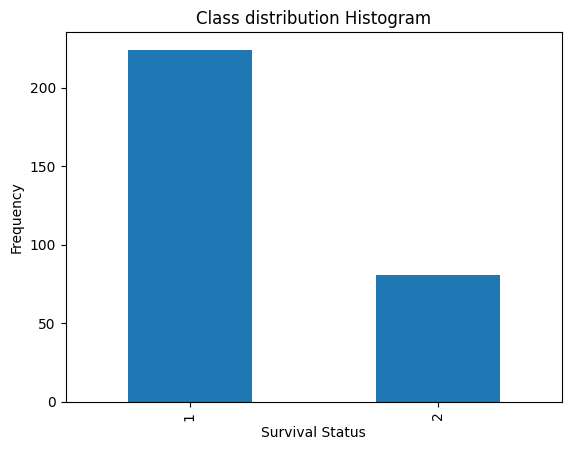

***********************************************************
PatientYearOperation
58    36
64    30
63    30
65    28
60    28
66    28
59    27
61    26
67    25
62    23
68    13
69    11
Name: count, dtype: int64

In Percentage:
PatientYearOperation
58    0.118033
64    0.098361
63    0.098361
65    0.091803
60    0.091803
66    0.091803
59    0.088525
61    0.085246
67    0.081967
62    0.075410
68    0.042623
69    0.036066
Name: proportion, dtype: float64


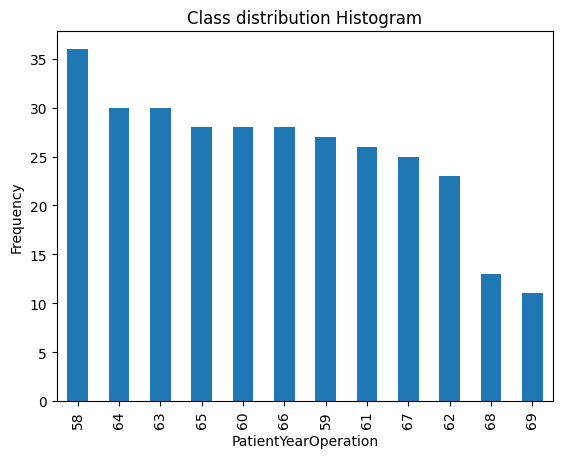

In [35]:
print(df["SurvivalStatus"].value_counts())

print("\nIn Percentage:")
print(df['SurvivalStatus'].value_counts(normalize = True) ) # in  percent

# plot the histogram for the classes - binary classification, only two classes
count_classes = pd.Series(df["SurvivalStatus"]).value_counts()
count_classes.plot(kind = 'bar')
plt.title("Class distribution Histogram")
plt.xlabel("Survival Status")
plt.ylabel("Frequency")
plt.show()

print("***********************************************************")
print(df["PatientYearOperation"].value_counts())

print("\nIn Percentage:")
print(df['PatientYearOperation'].value_counts(normalize = True) ) # in  percent

# plot the histogram for the classes
count_classes = pd.Series(df["PatientYearOperation"]).value_counts()
count_classes.plot(kind = 'bar')
plt.title("Class distribution Histogram")
plt.xlabel("PatientYearOperation")
plt.ylabel("Frequency")
plt.show()



## Observations
A quick look at the count of records for the attributes “age” and “year”(when the operation was performed) gives us the following insights.

- We have more patients with a survival status of 1(those who survived for more than 5 years or longer) than patients with a survival status of 2(those who died within 5 years). Around 73% of the patients survived after the surgery whereas around 26% of the patients, unfortunately, died within 5 years of surgery.
- As the number of records existing for both survival rates has a major difference, **our data is imbalanced**.
- In the year 1958, most of the operations were performed and the least operations were performed in 1969

In [36]:
unique_valuesList = list(df["SurvivalStatus"].unique())
print(df.info())
print("\nThe Unique values in the class attribute column are : {}".format(unique_valuesList))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   PatientAge            305 non-null    int64
 1   PatientYearOperation  305 non-null    int64
 2   NumberAxillaryNodes   305 non-null    int64
 3   SurvivalStatus        305 non-null    int64
dtypes: int64(4)
memory usage: 9.7 KB
None

The Unique values in the class attribute column are : [1, 2]


**_Observation(s) :_**
1. The total number of observations/data points are 305.
2. We can now confirm that all the columns in the dataset are numeric.
3. There are no missing values in the dataset.
4. Since the SurvivalStatus column is the class attribute, it's data-type need to be changed from numeric to categorical datatype.
5. The Survival Status can be mapped as 'Survived' for those patients who survived after surgery and 'Died' for those patients who unfortunately died within 5 years after surgery. That is, 1 -> 'Survived and 2 -> 'Died'

In [37]:
# Data Preprocessing
# Since the class attributes of the dataset i.e Survival Status is numeric, it needs to properly mapped.
# 1 -> 'Survived' and 2 -> 'Died'

df["SurvivalStatus"] = df["SurvivalStatus"].replace({1: "Survived",2: "Died"})

print(df.head(5))
print("#####################")
print(df.info())
print("----------------------")
print(df.describe())

   PatientAge  PatientYearOperation  NumberAxillaryNodes SurvivalStatus
0          30                    62                    3       Survived
1          30                    65                    0       Survived
2          31                    59                    2       Survived
3          31                    65                    4       Survived
4          33                    58                   10       Survived
#####################
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   PatientAge            305 non-null    int64 
 1   PatientYearOperation  305 non-null    int64 
 2   NumberAxillaryNodes   305 non-null    int64 
 3   SurvivalStatus        305 non-null    object
dtypes: int64(3), object(1)
memory usage: 9.7+ KB
None
----------------------
       PatientAge  PatientYearOperation  NumberAxillaryNodes
cou

**_Observation(s) :_**
1. The dataset consists of data for 305 patients recorded between the year 1958 to 1969.
2. Attributes such as Patient's Age, Patient's year of operation and the number of positive axillary nodes detected contribute towards the classification of the class attribute i.e. Survival Status.
3. The Patient's age varies between 30 and 83 having an average age of 52.
4. The number of positive axillary nodes vary between 0 to 52, having the average number of detected nodes to be 4.
5. About 25% of the patients are having no positive axillary nodes detected and about 75% of the patients have less than 5 axillary nodes detected.

In [38]:
print(df.isnull().any())
print("--------------------------")
print(df.count())

PatientAge              False
PatientYearOperation    False
NumberAxillaryNodes     False
SurvivalStatus          False
dtype: bool
--------------------------
PatientAge              305
PatientYearOperation    305
NumberAxillaryNodes     305
SurvivalStatus          305
dtype: int64


**_Observation(s) :_**
1. The dataset does not contain any NA/null/NaN values with every feature having 305 observations each.

## Univariate Analysis

Univariate analysis is the simplest form of analyzing data. “Uni” means “one”, so in other words, your data has only one variable. It doesn’t deal with causes or relationships (unlike regression) and its major purpose is to describe; it takes data, summarizes that data and finds patterns in the data.


**_PDF - CDF Plots :_**

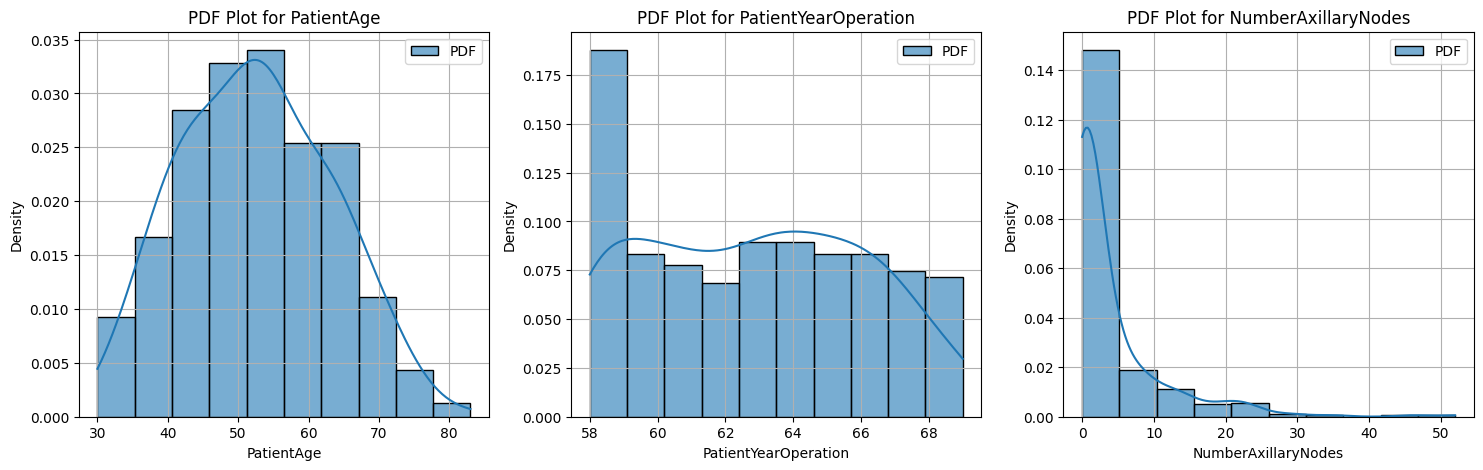

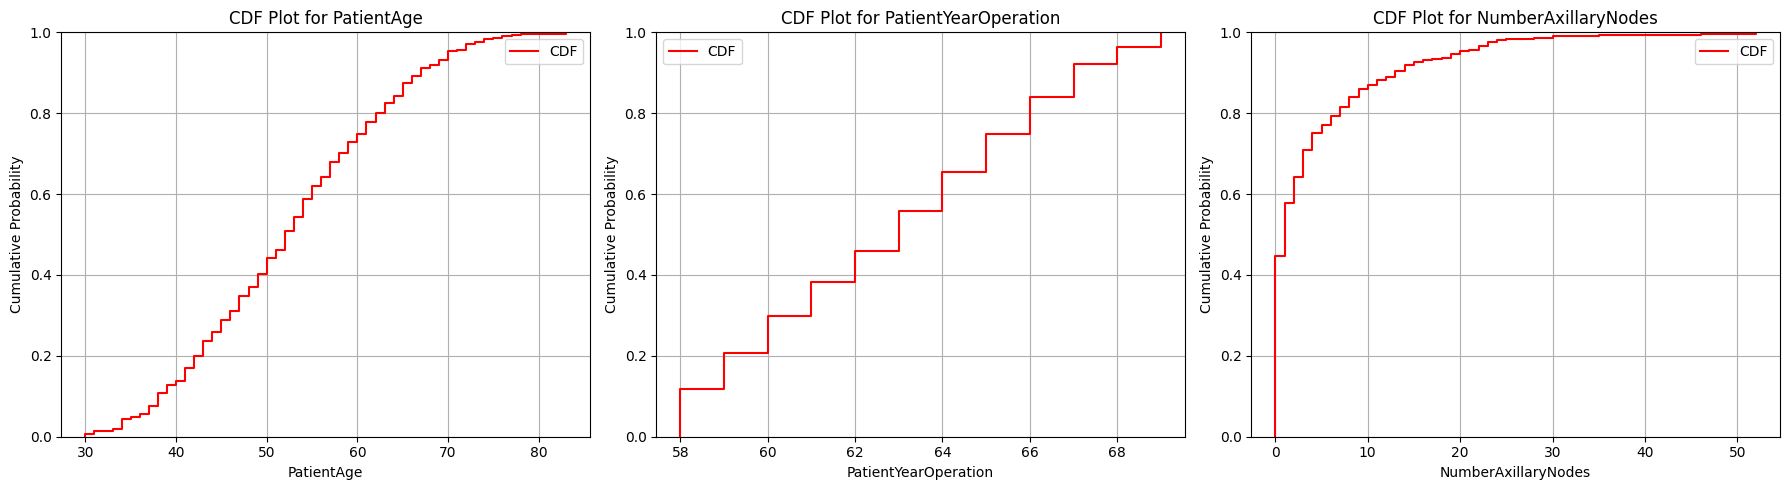

In [39]:
plt.close('all')  # Close previous plots
numeric_cols = ['PatientAge','PatientYearOperation', 'NumberAxillaryNodes']

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig1, axes1 = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))  # Histogram + KDE
fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))  # CDF


for i, feature in enumerate(list(df.columns)[:-1]):
    # Histogram + KDE (PDF)
    sns.histplot(df[feature], bins=10, kde=True, ax=axes1[i], stat="density", alpha=0.6, label="PDF")
    axes1[i].set_title(f"PDF Plot for {feature}")
    axes1[i].set_xlabel(feature)
    axes1[i].set_ylabel("Density")
    axes1[i].legend()
    axes1[i].grid()

    # CDF Plot
    sns.ecdfplot(df[feature], ax=axes2[i], color='red', label="CDF")
    axes2[i].set_title(f"CDF Plot for {feature}")
    axes2[i].set_xlabel(feature)
    axes2[i].set_ylabel("Cumulative Probability")
    axes2[i].legend()
    axes2[i].grid()

plt.tight_layout()
plt.show()


**_Observation(s):_**
1. About ~13% of the patients are below the age of 40 and we are having maximum patients between the age of 45-60. The PDF of the Patient Age graph shows that there are very less or zero(approaching) number of patients above the age of 80.
2. About ~30% of the operations happened between 1958 and 1960. We can also see that there was a sudden drop in the patients between the years 1961 to 1962.
3. About ~88% of the patients have less than 10 positive axillary nodes and about ~98% of the patients have less than 28 positive axillary nodes.

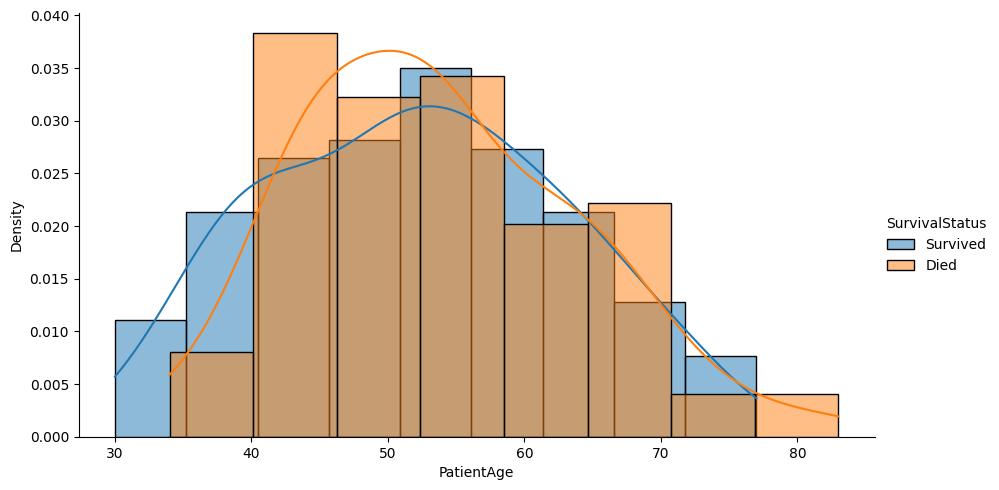

In [40]:
# sns.FacetGrid(df,hue='SurvivalStatus',height = 5,).map(sns.distplot,"PatientAge").add_legend();
g = sns.FacetGrid(df, hue='SurvivalStatus', height=5, aspect=1.8)
g.map(sns.histplot, "PatientAge", kde=True, stat="density", common_norm=False).add_legend()

plt.show()

## Observations

- Patients between the ages of 30–34 have survived for 5 years or longer(B/c of LHS light blue bar bulging out and high).
- Patients whose age is more than 75 died within 5 years of the operation(See the orange bar on RHS).
- The number of patients between the age of 40–50 is more for status 2(i.e those who died within 5 years)
- The number of patients between the age of 35–40 is more for status 1(i.e who have survived for 5 years or more), patients within this age group have a good chance of survival post the operation.

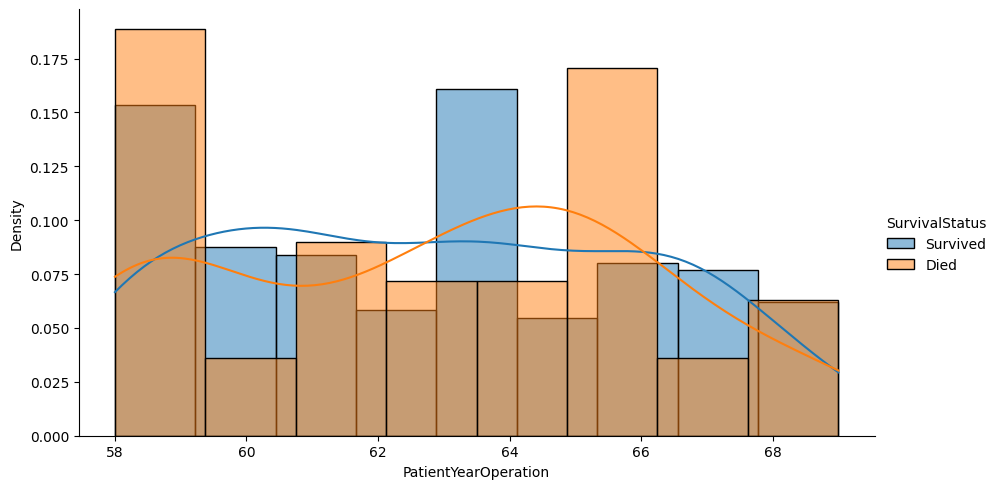

In [41]:
# sns.FacetGrid(df,hue='SurvivalStatus',height = 5,).map(sns.distplot,"PatientYearOperation").add_legend();
# Use FacetGrid to plot histogram with KDE for different SurvivalStatus
g = sns.FacetGrid(df, hue='SurvivalStatus', height=5, aspect=1.8)
g.map(sns.histplot, "PatientYearOperation", kde=True, stat="density", common_norm=False).add_legend()

plt.show()

## Observations

The data is overlapping but we can see that
- between 1963 and 1966 we have more data on patients who died within 5 years of the operation. (b/c the curve get higher)
- between 1958–1961 we have more data on patients who survived within 5 years of the operation.

**_Box-Plots :_**

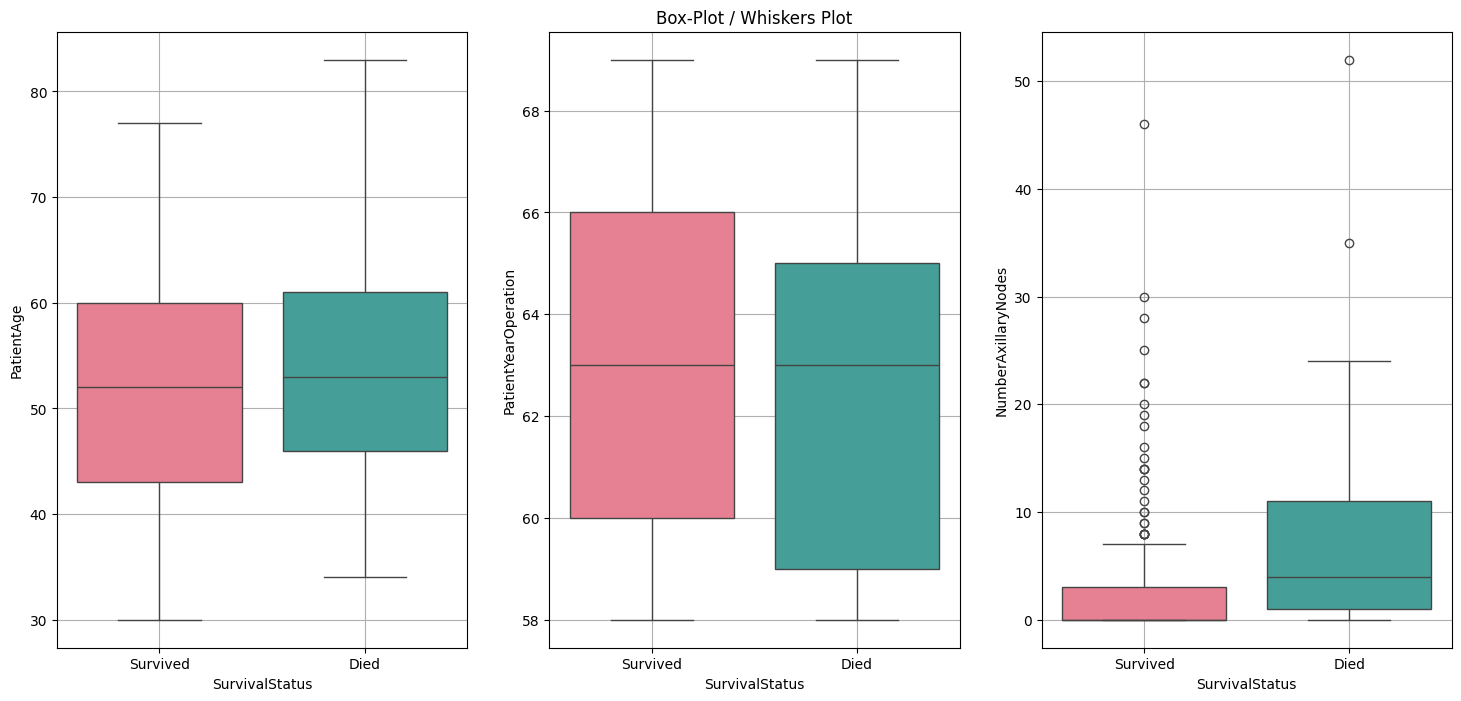

In [42]:
plt.close()
plt.figure(figsize=(18,8))
for index, columnY in enumerate(list(df.columns)[:-1]):
    plt.subplot(1, 3, index+1)
    sns.boxplot(x="SurvivalStatus",
                y=columnY,
                hue="SurvivalStatus",
                data=df,
                palette='husl')
    plt.grid()
plt.subplot(1, 3, 2)
plt.title("Box-Plot / Whiskers Plot")
plt.show()

## Observations on PatientAge:

- The 25th percentile of patients who have survived are of age approximate 42 years
- The 25th percentile of patients who died are of age approximate 46 years
- The 50th percentile of patients who have survived are of age approximate 52 years
- The 50th percentile of patients who died are of age approximate 55 years
- 75th percentile of patients who have survived are of age approximate 60 years
- 75th percentile of patients who died are of age approximate 61 years

As we have noted before the data is overlapping to a great extent and hence we would not be able to draw an accurate conclusion on the basis of just the age of the patient.


## Observations on PatientYearOperation  

We can see that for the nodes attribute we have some outlier points.

- 75 percentile of patients who survived have less than 4 nodes whereas 50 percentile of patients who could not survive have 5 nodes
- Having a low count of active nodes is definitely a contributing factor to the survival of a patient.


**_Additional Observation(s) :_**
1. The Patient's who are having age between 30 to 34 have survived 5 years or longer(Because, the min of survived is at 30 and min of Died is at 34). Also, the patients who are having age more than 77 have unfortunately died(The max of survived is at 77). However, the mean of both the survival status according to the patient's age is the same.
2. It is quite evident from the whisker's plot between survival status and patient's year of operation that patient who was undergoing an operation before 1960 and after 1965 had higher chances of survival. However, we cannot confirm the reason why! Confidently trying to infer from such graph is quite difficult.
3. The patients who are having less than 3 positive axillary nodes had higher chances for survival. Also, the patients who are having more than 10 positive Axillary nodes had very fewer chances of survival.
4. Thus, just by the overall conclusion, we can infer that the year of operation does not add any luck towards the classification.

**_Violin-Plot :_**
Violin plot is the combination of box plot and probability density function.

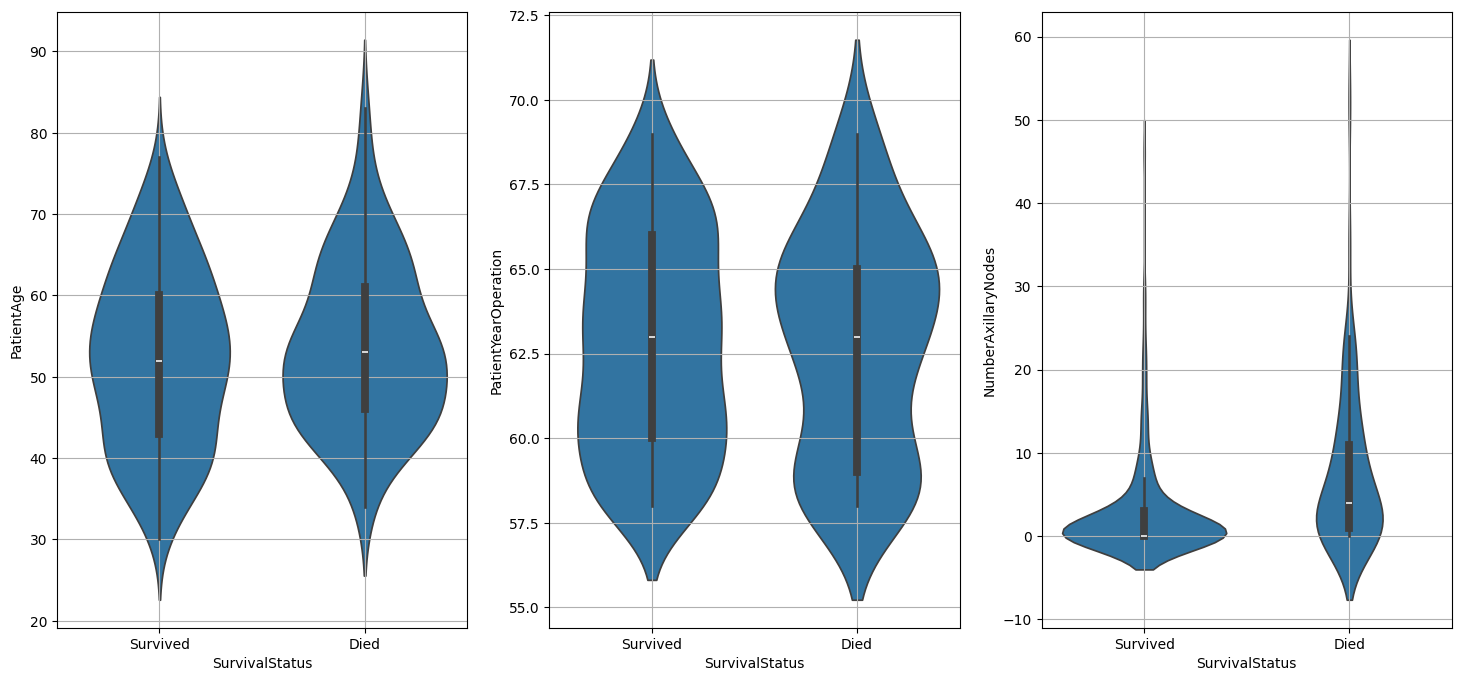

In [43]:
plt.close()
plt.figure(figsize=(18,8))
for index, columnY in enumerate(list(df.columns)[:-1]):
    plt.subplot(1, 3, index+1)
    sns.violinplot(x="SurvivalStatus", y=columnY, data=df)
    plt.grid()
plt.show()

**_Observation(s) :_**
1. The Violin plot between the axillary nodes and the survival status shows that the probability of the patients surviving after the operations is high when the number of positive axillary nodes are less than ~5(Becasue the PDF shows spike before 5).

## Strip plot — 1-D scatter plot
It produces one dimensional scatter plots (or dot plots) of the given data.

A strip plot is a scatter plot where one of the variables is categorical and we can group data based on this categorical variable.

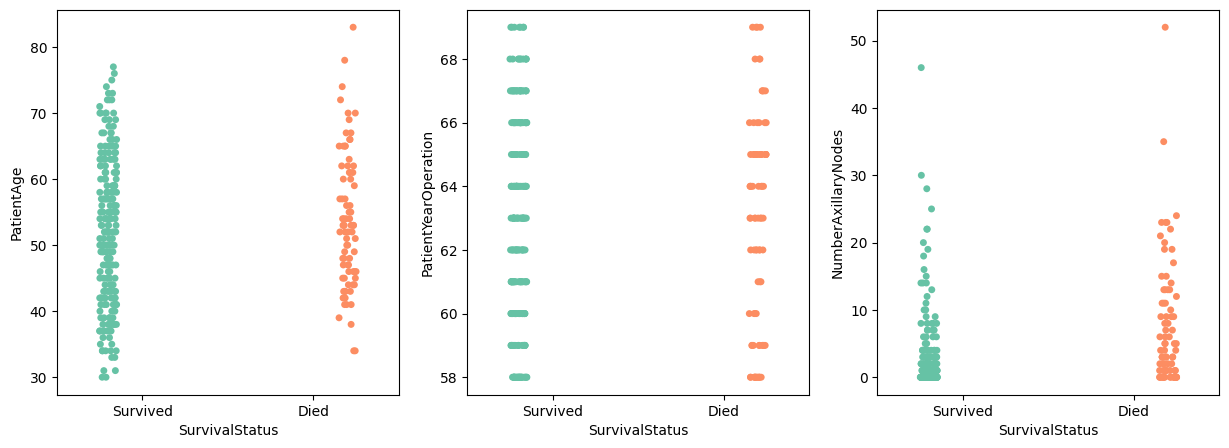

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, feature in enumerate(list(df.columns)[:-1]):
    sns.stripplot(x='SurvivalStatus',
                  y=feature, 
                  data=df,
                  ax=axes[idx], 
                  hue='SurvivalStatus',
                  palette='Set2',
                  dodge=True, 
                  jitter=True
    )
plt.show()

##Observation
Not much meaning ful info here

## Bivariate Analysis

Bivariate analysis is the simultaneous analysis of two variables (attributes). It explores the concept of the relationship between two variables, whether there exists an association and the strength of this association, or whether there are differences between the two variables and the significance of these differences. There are three types of bivariate analysis. 

    1. Numerical & Numerical
    2. Categorical & Categorical
    3. Numerical & Categorical

**_Scatter-Plot :_**

Lets draw scatter plot between
- "PatientAge", "NumberAxillaryNodes"
- "PatientAge", "PatientYearOperation"
- "NumberAxillaryNodes", "PatientYearOperation"

(We could have drawn more pair plots)

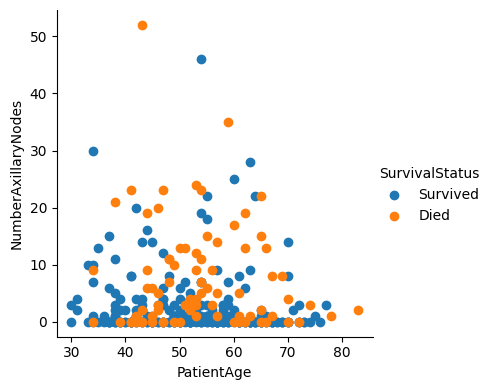

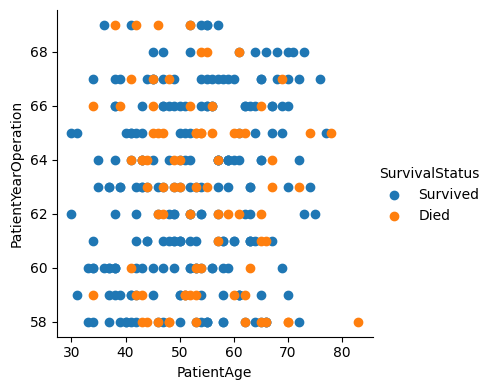

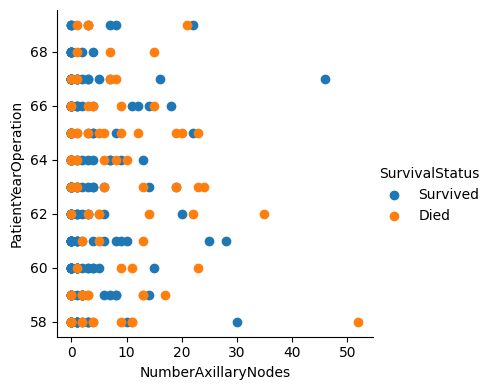

In [45]:

a = sns.FacetGrid(data=df, hue="SurvivalStatus", height=4)\
    .map(plt.scatter, "PatientAge", "NumberAxillaryNodes")\
    .add_legend()

b = sns.FacetGrid(data=df, hue="SurvivalStatus", height=4)\
    .map(plt.scatter, "PatientAge", "PatientYearOperation")\
    .add_legend()

c = sns.FacetGrid(data=df, hue="SurvivalStatus", height=4)\
    .map(plt.scatter, "NumberAxillaryNodes", "PatientYearOperation")\
    .add_legend()
plt.show()

**_Observation(s) :_**
1. The features are **not linearly** seperable. All the features are highly dense.
2. We cannot differentiate between the features using if-else conditions. Complex algorithm processing will be required in order to infer from it.

**_Pair-Plot :_**

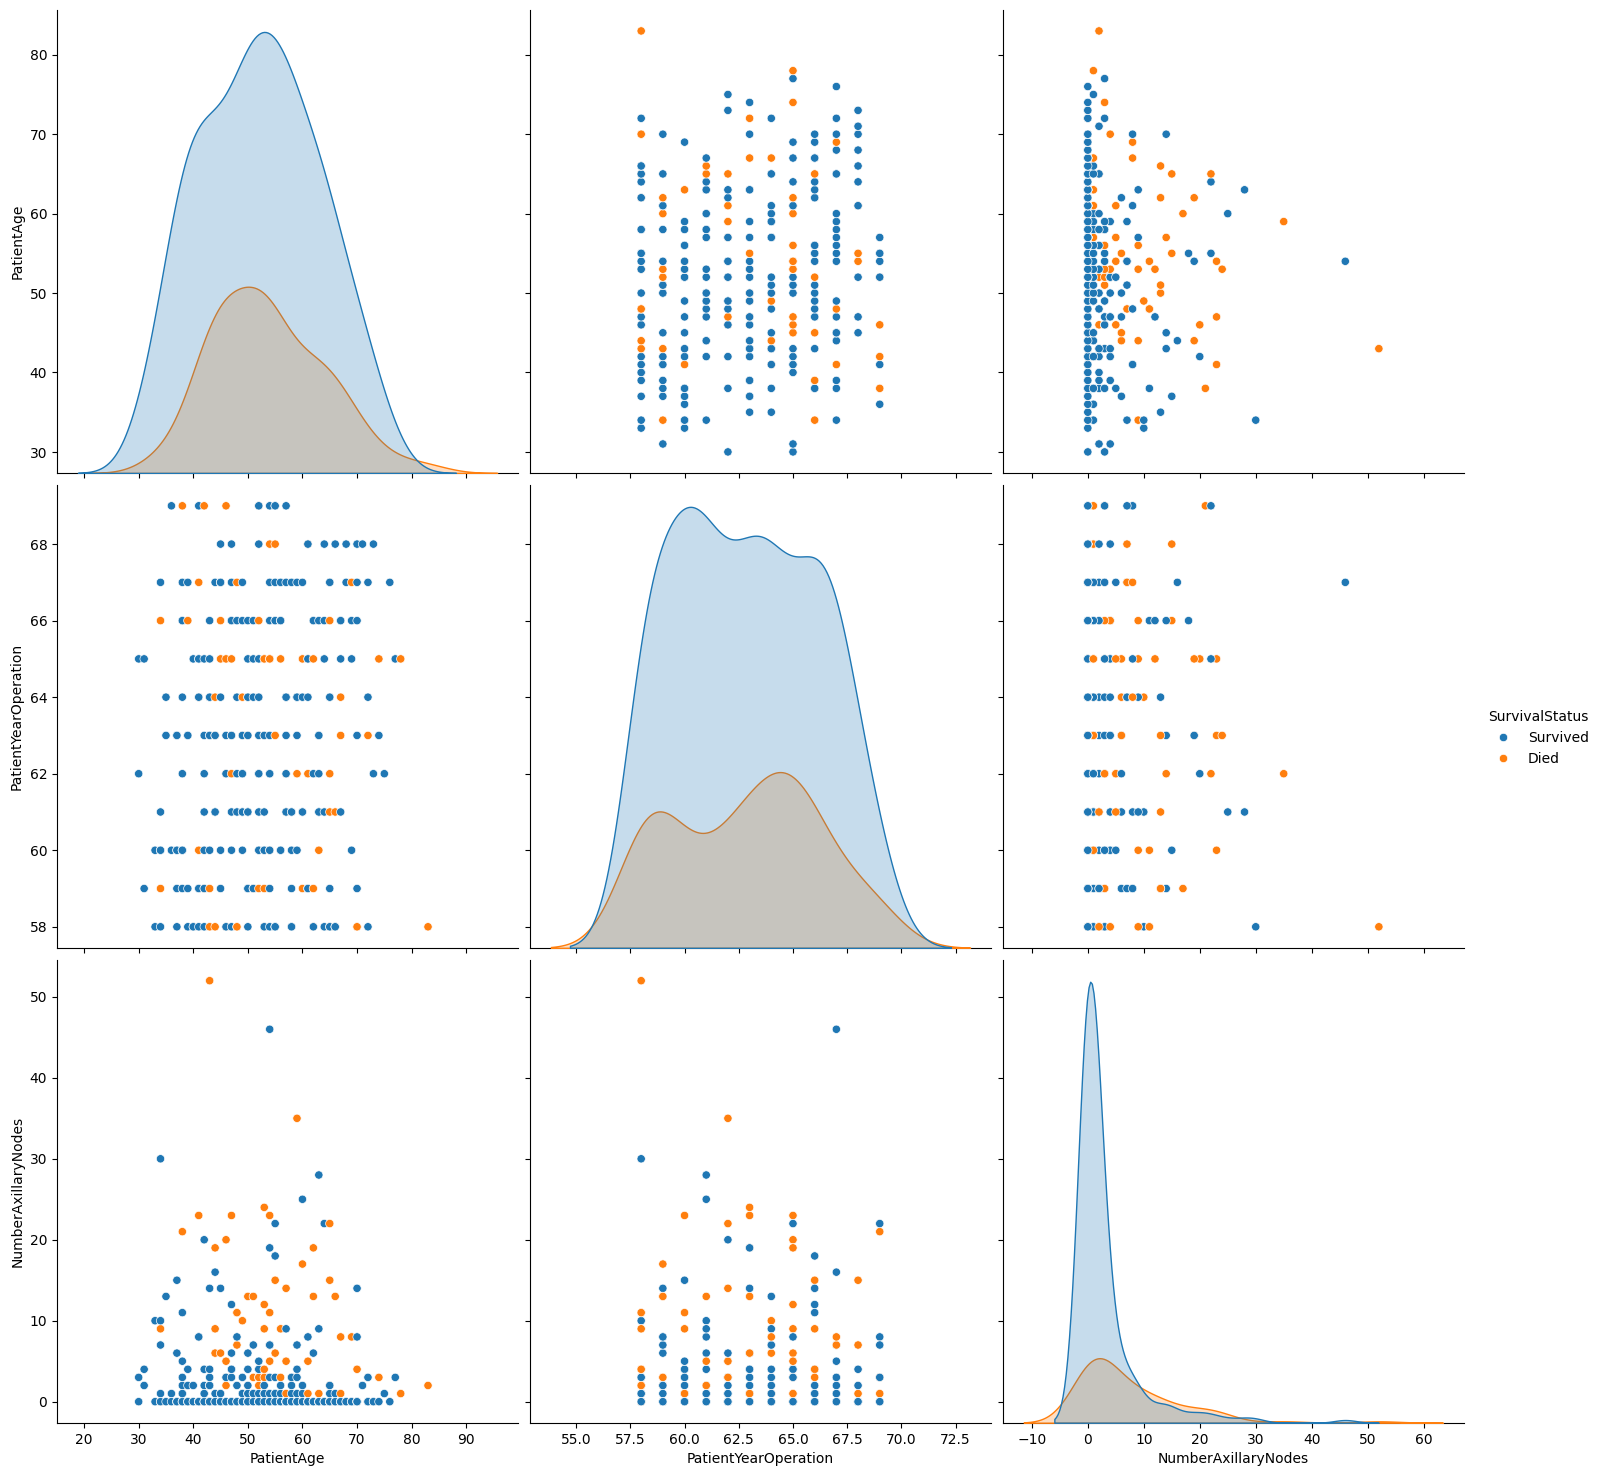

In [46]:
plt.close()
sns.pairplot(data=df, hue="SurvivalStatus", height=5)
plt.grid()
plt.show()

**_Observation(s) :_**
1. The Patient's year of operation doesn't seem to have an effect on the classification(Because the survived/died points are interleaved).
2. The Patient's Age and the number of axillary nodes seems to add some little/minor useful characteristics to the classification(Because the survived/died points are NOT so much interleaved). We can see that patients with more number of nodes(>5) and high age(>50) are generally of status 2(who could not survive)
3. However, Bivariate analysis of the Haberman's data set is not much help.

# multivariate (SKIP THIS PART..not very informative and hard to understand/interpret)

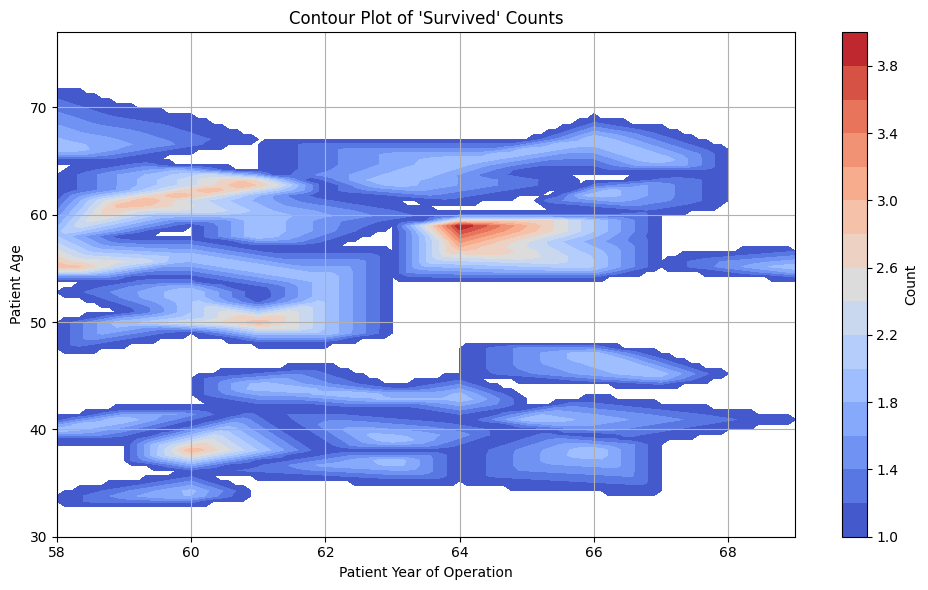

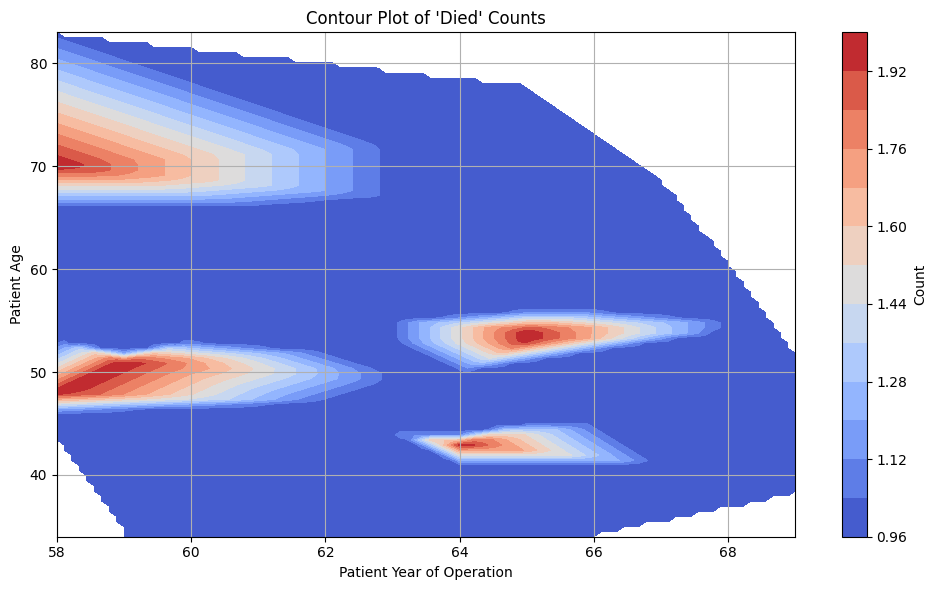

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Step 1: Group data
grouped = df.groupby(['PatientYearOperation', 'PatientAge', 'SurvivalStatus']).size().reset_index(name='count')

# Separate for 'survived' and 'died'
for status in ['Survived', 'Died']:
    subset = grouped[grouped['SurvivalStatus'] == status]

    # Step 2: Interpolate count to create a grid
    x = subset['PatientYearOperation']
    y = subset['PatientAge']
    z = subset['count']

    xi = np.linspace(x.min(), x.max(), 100)
    yi = np.linspace(y.min(), y.max(), 100)
    xi, yi = np.meshgrid(xi, yi)
    zi = griddata((x, y), z, (xi, yi), method='linear')

    # Step 3: Plot contour
    plt.figure(figsize=(10, 6))
    contour = plt.contourf(xi, yi, zi, cmap='coolwarm', levels=15)
    plt.title(f"Contour Plot of '{status.capitalize()}' Counts")
    plt.xlabel("Patient Year of Operation")
    plt.ylabel("Patient Age")
    plt.colorbar(contour, label='Count')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## observation


**CONCLUSION**

Considering the above plots, just by the overall look, we can say that the plots of the attributes are highly overlapped. An inference from such plots would be quite difficult.

But, the patient's age and the number of positive axillary nodes have some useful characteristics for classification which can be more revealed by more advanced machine learning algorithms.